# Hows ADABoost works

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions  # how ML divides the classifer space
import warnings
warnings.filterwarnings('ignore')

In [129]:
# make the datafram

df = pd.DataFrame()

In [130]:
df['X1'] = [1, 2, 3, 4, 6, 7, 8, 9, 2]
df['X2'] = [4, 7, 2, 5, 4, 6, 3, 8, 9]
df['label'] = [1, 1, 1, 0, 1, 0, 0, 0, 0]

In [131]:
# Data set
df

,X1,X2,label
0,1,4,1
1,2,7,1
2,3,2,1
3,4,5,0
4,6,4,1
5,7,6,0
6,8,3,0
7,9,8,0
8,2,9,0


Text(0.5, 1.0, 'Scatter points of current points')

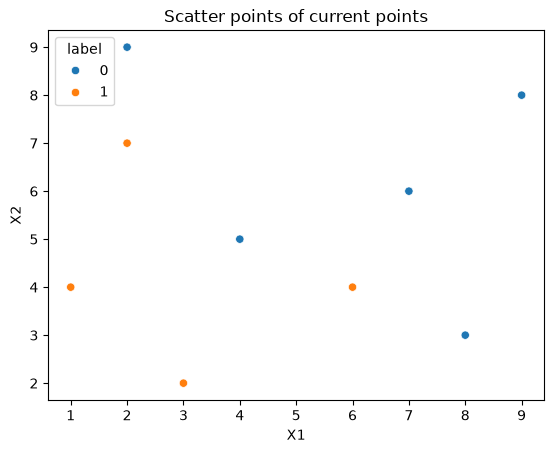

In [132]:
# check how scatter the points are 

import seaborn as sns
sns.scatterplot(x=df['X1'], y=df['X2'], hue=df['label'])
plt.title("Scatter points of current points")

In [133]:
# Assign equal weights to each datapoint

df['weights'] = 1/df.shape[0]   # divide by total num of rows.

In [134]:
df # current weights = 0.111

,X1,X2,label,weights
0,1,4,1,0.111111
1,2,7,1,0.111111
2,3,2,1,0.111111
3,4,5,0,0.111111
4,6,4,1,0.111111
5,7,6,0,0.111111
6,8,3,0,0.111111
7,9,8,0,0.111111
8,2,9,0,0.111111


In [135]:
# Train the dataset on Decision tree classifer with 1 stump (max_depth=1)

from sklearn.tree import DecisionTreeClassifier

dt1 = DecisionTreeClassifier(max_depth=1)

X = df.iloc[:, 0:2].values
y = df.iloc[:, 2].values

# Train the first DT model
dt1.fit(X, y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

[Text(0.5, 0.75, 'x[0] <= 6.5\ngini = 0.494\nsamples = 9\nvalue = [5, 4]\nclass = 0'),
 Text(0.25, 0.25, 'gini = 0.444\nsamples = 6\nvalue = [2, 4]\nclass = 1'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]\nclass = 0'),
 Text(0.625, 0.5, '  False')]

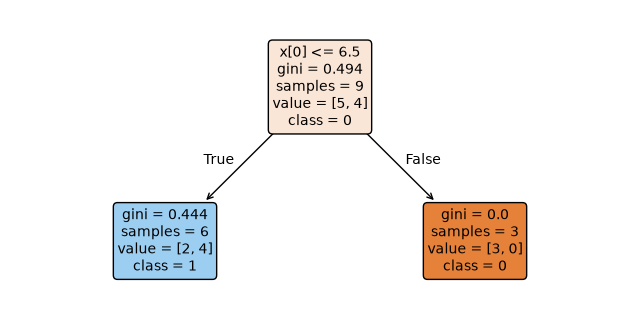

In [136]:
# Plot the tree 
plt.figure(figsize=(8,4))
from sklearn.tree import plot_tree
plot_tree(dt1, class_names=['0', '1'], filled=True, rounded=True, fontsize=10)

# as per out data
# values 0-4 are Class 1 -- these values are 0,1,2,3,4 - -from X1
# values 5-9 are Class 0 -- these values are 5,6,7,8,9 - -from X1
# ONLY X1=10 is predicated as Class 1


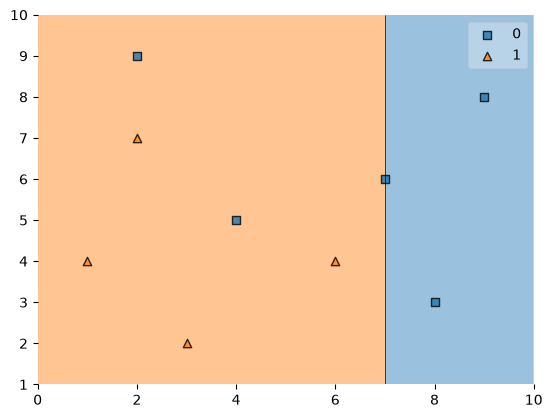

In [137]:
# Plot the decision regions for the d1t model

plot_decision_regions(X, y, clf=dt1, legend=1)
plt.show()

# we can see by 1 split only the single value is misclassified as seen in the data

In [138]:
# make preditions on input data
df['y_pred'] = dt1.predict(X)

df
# as seen in the above split, only 1 point is misclassified

,X1,X2,label,weights,y_pred
0,1,4,1,0.111111,1
1,2,7,1,0.111111,1
2,3,2,1,0.111111,1
3,4,5,0,0.111111,1
4,6,4,1,0.111111,1
5,7,6,0,0.111111,0
6,8,3,0,0.111111,0
7,9,8,0,0.111111,0
8,2,9,0,0.111111,1


In [139]:
# Now we calculate the models weight by passing total error made by the model as parameter to it

def calculate_model_weight(error):
    return 0.5*np.log((1-error)/(error+0.000001))   # to avoid divison by error=0

In [140]:
# Calculate alph1 for the model dt1

alpha1 = calculate_model_weight(0.222222)  # rows with error - 3, 8 & 0.222222 is the total error of misclassified rows
alpha1

np.float64(0.6263798771078689)

In [141]:
# Update the weights of model which had missclassified rows
def update_row_weights(row,alpha=0.626):
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)    # when the predicitons are correct we decrese the weights of model
    else:
        return row['weights'] * np.exp(alpha)    # when the predicitons are wrong we increase the weights of model

In [142]:
df['updated_weights'] = df.apply(update_row_weights, axis=1)  # update the weigth of each row, pass the whole dataset to the function and update the weights 

df

# from the dataset as we can see if the predictions are correct the weights are decreased , and weights are increased if wrong

,X1,X2,label,weights,y_pred,updated_weights
0,1,4,1,0.111111,1,0.059414
1,2,7,1,0.111111,1,0.059414
2,3,2,1,0.111111,1,0.059414
3,4,5,0,0.111111,1,0.207791
4,6,4,1,0.111111,1,0.059414
5,7,6,0,0.111111,0,0.059414
6,8,3,0,0.111111,0,0.059414
7,9,8,0,0.111111,0,0.059414
8,2,9,0,0.111111,1,0.207791


In [143]:
df['updated_weights'].sum()     # the sum of updated_weights should be max close to 1 , if not **Normalize** the weights

np.float64(0.8314794797857948)

In [144]:
# Perform Normalization on each weights
df['normalized_weights'] = df['updated_weights']/df['updated_weights'].sum()

df

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights
0,1,4,1,0.111111,1,0.059414,0.071456
1,2,7,1,0.111111,1,0.059414,0.071456
2,3,2,1,0.111111,1,0.059414,0.071456
3,4,5,0,0.111111,1,0.207791,0.249905
4,6,4,1,0.111111,1,0.059414,0.071456
5,7,6,0,0.111111,0,0.059414,0.071456
6,8,3,0,0.111111,0,0.059414,0.071456
7,9,8,0,0.111111,0,0.059414,0.071456
8,2,9,0,0.111111,1,0.207791,0.249905


In [145]:
df['normalized_weights'].sum()   # now check the sum of normalized weights

np.float64(1.0)

In [146]:
# Provide a range for each row

df['upper_range'] = np.cumsum(df['normalized_weights'])
df['lower_range'] = df['upper_range'] - df['normalized_weights']

In [147]:
df  # updated ranges

,X1,X2,label,weights,y_pred,updated_weights,normalized_weights,upper_range,lower_range
0,1,4,1,0.111111,1,0.059414,0.071456,0.071456,0.000000
1,2,7,1,0.111111,1,0.059414,0.071456,0.142912,0.071456
2,3,2,1,0.111111,1,0.059414,0.071456,0.214367,0.142912
3,4,5,0,0.111111,1,0.207791,0.249905,0.464272,0.214367
4,6,4,1,0.111111,1,0.059414,0.071456,0.535728,0.464272
5,7,6,0,0.111111,0,0.059414,0.071456,0.607184,0.535728
6,8,3,0,0.111111,0,0.059414,0.071456,0.678640,0.607184
7,9,8,0,0.111111,0,0.059414,0.071456,0.750095,0.678640
8,2,9,0,0.111111,1,0.207791,0.249905,1.000000,0.750095


In [148]:
# Now create a new dataframe by using the above range

def create_new_database(df):
    indices = []

    for i in range(df.shape[0]):
        a = np.random.random()

        for index,row in df.iterrows():
            if (row['lower_range'] < a < row['upper_range']):
                indices.append(index)
    return indices

In [149]:
index_values = create_new_database(df)

index_values

# this is what "Upsampling" means


[5, 3, 0, 8, 4, 1, 2, 1, 7]

In [150]:
# Build 2nd dataframe with the rows of index values from above

second_df = df.iloc[index_values, [0,1,2,3]]
second_df

,X1,X2,label,weights
5,7,6,0,0.111111
3,4,5,0,0.111111
0,1,4,1,0.111111
8,2,9,0,0.111111
4,6,4,1,0.111111
1,2,7,1,0.111111
2,3,2,1,0.111111
1,2,7,1,0.111111
7,9,8,0,0.111111


In [151]:
# Again do the same DT classifier with depth 1

dt2 = DecisionTreeClassifier(max_depth=1)

X2 = second_df.iloc[:, 0:2].values
y2 = second_df.iloc[:, 2].values

# Train the second DT model
dt2.fit(X2, y2)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

[Text(0.5, 0.75, 'x[1] <= 4.5\ngini = 0.494\nsamples = 9\nvalue = [4, 5]\nclass = 1'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]\nclass = 1'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.444\nsamples = 6\nvalue = [4, 2]\nclass = 0'),
 Text(0.625, 0.5, '  False')]

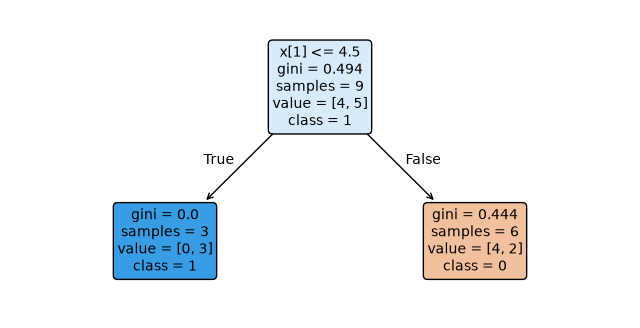

In [152]:
# Plot the tree 
plt.figure(figsize=(8,4))
from sklearn.tree import plot_tree
plot_tree(dt2, class_names=['0', '1'], filled=True, rounded=True, fontsize=10)


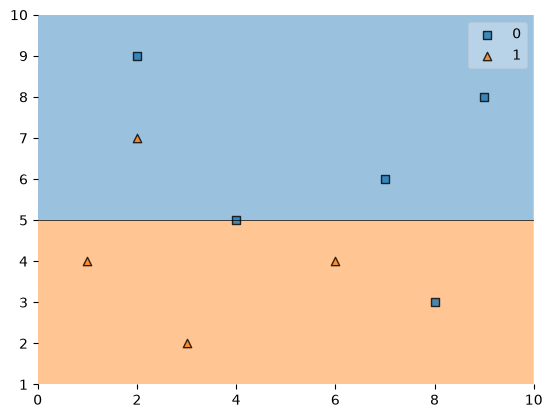

In [153]:
# Plot the decision regions for the d1t model

plot_decision_regions(X, y, clf=dt2, legend=1)
plt.show()


In [158]:
second_df['y_pred'] = dt2.predict(X2)
second_df

,X1,X2,label,weights,y_pred,updated_weights
5,7,6,0,0.111111,0,0.124155
3,4,5,0,0.111111,0,0.124155
0,1,4,1,0.111111,1,0.124155
8,2,9,0,0.111111,0,0.124155
4,6,4,1,0.111111,1,0.124155
1,2,7,1,0.111111,0,0.099438
2,3,2,1,0.111111,1,0.124155
1,2,7,1,0.111111,0,0.099438
7,9,8,0,0.111111,0,0.124155


In [159]:
# now the model made 5 mistakes -- so total error = 0.555555

alpha2 = calculate_model_weight(0.111111)
alpha2

np.float64(1.039716833355914)

In [160]:
# update the model weights

def update_row_weights(row,alpha=-0.111):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [161]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)

second_df

,X1,X2,label,weights,y_pred,updated_weights
5,7,6,0,0.111111,0,0.124155
3,4,5,0,0.111111,0,0.124155
0,1,4,1,0.111111,1,0.124155
8,2,9,0,0.111111,0,0.124155
4,6,4,1,0.111111,1,0.124155
1,2,7,1,0.111111,0,0.099438
2,3,2,1,0.111111,1,0.124155
1,2,7,1,0.111111,0,0.099438
7,9,8,0,0.111111,0,0.124155


In [162]:
# Normalize the weighhts

second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()
second_df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
5,7,6,0,0.111111,0,0.124155,0.116254
3,4,5,0,0.111111,0,0.124155,0.116254
0,1,4,1,0.111111,1,0.124155,0.116254
8,2,9,0,0.111111,0,0.124155,0.116254
4,6,4,1,0.111111,1,0.124155,0.116254
1,2,7,1,0.111111,0,0.099438,0.093110
2,3,2,1,0.111111,1,0.124155,0.116254
1,2,7,1,0.111111,0,0.099438,0.093110
7,9,8,0,0.111111,0,0.124155,0.116254


In [163]:
second_df['nomalized_weights'].sum()

np.float64(0.9999999999999999)

In [164]:
second_df['upper_range'] = np.cumsum(second_df['nomalized_weights'])
second_df['lower_range'] = second_df['upper_range'] - second_df['nomalized_weights']

second_df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights,upper_range,lower_range
5,7,6,0,0.111111,0,0.124155,0.116254,0.116254,0.000000
3,4,5,0,0.111111,0,0.124155,0.116254,0.232509,0.116254
0,1,4,1,0.111111,1,0.124155,0.116254,0.348763,0.232509
8,2,9,0,0.111111,0,0.124155,0.116254,0.465017,0.348763
4,6,4,1,0.111111,1,0.124155,0.116254,0.581272,0.465017
1,2,7,1,0.111111,0,0.099438,0.093110,0.674381,0.581272
2,3,2,1,0.111111,1,0.124155,0.116254,0.790636,0.674381
1,2,7,1,0.111111,0,0.099438,0.093110,0.883746,0.790636
7,9,8,0,0.111111,0,0.124155,0.116254,1.000000,0.883746


In [ ]:
# these steps gets repeated for the number of times we provide n_estimators.

# if its 50, we get 50 alpha values and all of them are calculated which gives high accuracy